# **Medición del nivel de apropiación TIC en la comunidad de Puerto Gaitan**
#### Trabajo final - Karen Mejía Sánchez, ID 000581891

#### Aprendizaje de máquina - Maestría en ciencia de datos

### **Lectura de datos**

In [2]:
import pandas as pd

file_path = '/content/Medicion_del_nivel_de_apropiacion_TIC_en_la_comunidad_de_Puerto_Gaitan.csv'
df = pd.read_csv(file_path, sep=';')
display(df.head())

,Nombre,Edad,Genero,¿Con qué dispositivos tecnológicos te conectas regularmente?,¿Mayormente utilizas internet en tu vida diaria para,¿Has recibido formación formal sobre el uso de Tecnologías de la Información y Comunicaciones?,¿Cuáles son las principales barreras que enfrentas para utilizar las Tecnologías de la Información y Comunicaciones?,¿Te gustaría recibir formación sobre las Tecnologías de la Información y Comunicaciones?,¿Con qué frecuencia accedes a internet?,¿Qué tan importante consideras el uso de Tecnologías de la Información y Comunicaciones en tu vida diaria?,¿Cuál es tu nivel educativo?,¿A que grupo poblacional pertences?,¿Cómo calificarías tu habilidad para utilizar tecnologías digitales en tu vida diaria?
0,juan ulloa,18-24,Masculino,Celular,Estudio,Ninguno,Falta de acceso,Si,Diariamente,Muy importante,Pregrado,Ninguno,Muy alta
1,Julieth Natalia Cañas Sendoya,25-34,Femenino,Celular,Trabajo,Ninguno,Ninguna,No,Diariamente,Muy importante,Técnica o tecnólogo,Ninguno,Media
2,Leidy Yoana,25-34,Otros,Celular,Estudio,Ninguno,Ninguna,No,Diariamente,Muy importante,Secundaria,Ninguno,Muy alta
3,Raul mesa,18-24,Masculino,Celular,Trabajo,Ninguno,Ninguna,Tal vez,Diariamente,Muy importante,Secundaria,Indígena,Media
4,Sairy correa,0 -18,Femenino,Celular,Estudio,Autoaprendizaje,Falta de habilidades,No,Diariamente,Importante,Técnica o tecnólogo,Ninguno,Media


## **Preparación de datos**

In [3]:
# Tamaño del dataframe
df.shape

(1376, 13)

In [4]:
# Tipos de datos en el dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1376 entries, 0 to 1375
Data columns (total 13 columns):
 #   Column                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                --------------  ----- 
 0   Nombre                                                                                                                1375 non-null   object
 1   Edad                                                                                                                  1376 non-null   object
 2   Genero                                                                                                                1376 non-null   object
 3   ¿Con qué dispositivos tecnológicos te conectas regularmente?                                                          1376 non-null   object
 4   ¿Mayormente 

In [5]:
import unicodedata

def clean_special_characters(df):
    """
    Limpia caracteres especiales (como tildes), reemplaza espacios por guiones bajos y elimina signos de interrogación
    de todas las columnas de tipo string y de los nombres de las columnas en un DataFrame.
    """
    df_cleaned = df.copy()

    # Limpiar nombres de columnas
    new_columns = []
    for col in df_cleaned.columns:
        cleaned_col = unicodedata.normalize('NFKD', str(col)).encode('ascii', 'ignore').decode('utf-8')
        cleaned_col = cleaned_col.replace(' ', '_')  # Reemplazar espacios por guiones bajos
        cleaned_col = cleaned_col.replace('?', '')   # Eliminar signos de interrogación
        new_columns.append(cleaned_col)
    df_cleaned.columns = new_columns

    # Limpiar valores en columnas de tipo string
    for col in df_cleaned.select_dtypes(include=['object']).columns:
        df_cleaned[col] = df_cleaned[col].apply(lambda x: unicodedata.normalize('NFKD', str(x)).encode('ascii', 'ignore').decode('utf-8') if pd.notna(x) else x)
    return df_cleaned

# Aplicar la función de limpieza al DataFrame
df_cleaned = clean_special_characters(df)

display(df_cleaned.head())

,Nombre,Edad,Genero,Con_que_dispositivos_tecnologicos_te_conectas_regularmente,Mayormente_utilizas_internet_en_tu_vida_diaria_para,Has_recibido_formacion_formal_sobre_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones,Cuales_son_las_principales_barreras_que_enfrentas_para_utilizar_las_Tecnologias_de_la_Informacion_y_Comunicaciones,Te_gustaria_recibir_formacion_sobre_las_Tecnologias_de_la_Informacion_y_Comunicaciones,Con_que_frecuencia_accedes_a_internet,Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria,Cual_es_tu_nivel_educativo,A_que_grupo_poblacional_pertences,Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria
0,juan ulloa,18-24,Masculino,Celular,Estudio,Ninguno,Falta de acceso,Si,Diariamente,Muy importante,Pregrado,Ninguno,Muy alta
1,Julieth Natalia Canas Sendoya,25-34,Femenino,Celular,Trabajo,Ninguno,Ninguna,No,Diariamente,Muy importante,Tecnica o tecnologo,Ninguno,Media
2,Leidy Yoana,25-34,Otros,Celular,Estudio,Ninguno,Ninguna,No,Diariamente,Muy importante,Secundaria,Ninguno,Muy alta
3,Raul mesa,18-24,Masculino,Celular,Trabajo,Ninguno,Ninguna,Tal vez,Diariamente,Muy importante,Secundaria,Indigena,Media
4,Sairy correa,0 -18,Femenino,Celular,Estudio,Autoaprendizaje,Falta de habilidades,No,Diariamente,Importante,Tecnica o tecnologo,Ninguno,Media


In [6]:
# Convertir todas las variables a tipo categórica, excepto 'nombre'
for col in df_cleaned.columns:
    if col != 'Nombre':
        df_cleaned[col] = df_cleaned[col].astype('category')

print("\nDataFrame después de la conversión a categóricas (excepto 'nombre'):")
df_cleaned.info()


DataFrame después de la conversión a categóricas (excepto 'nombre'):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1376 entries, 0 to 1375
Data columns (total 13 columns):
 #   Column                                                                                                              Non-Null Count  Dtype   
---  ------                                                                                                              --------------  -----   
 0   Nombre                                                                                                              1375 non-null   object  
 1   Edad                                                                                                                1376 non-null   category
 2   Genero                                                                                                              1376 non-null   category
 3   Con_que_dispositivos_tecnologicos_te_conectas_regularmente                              

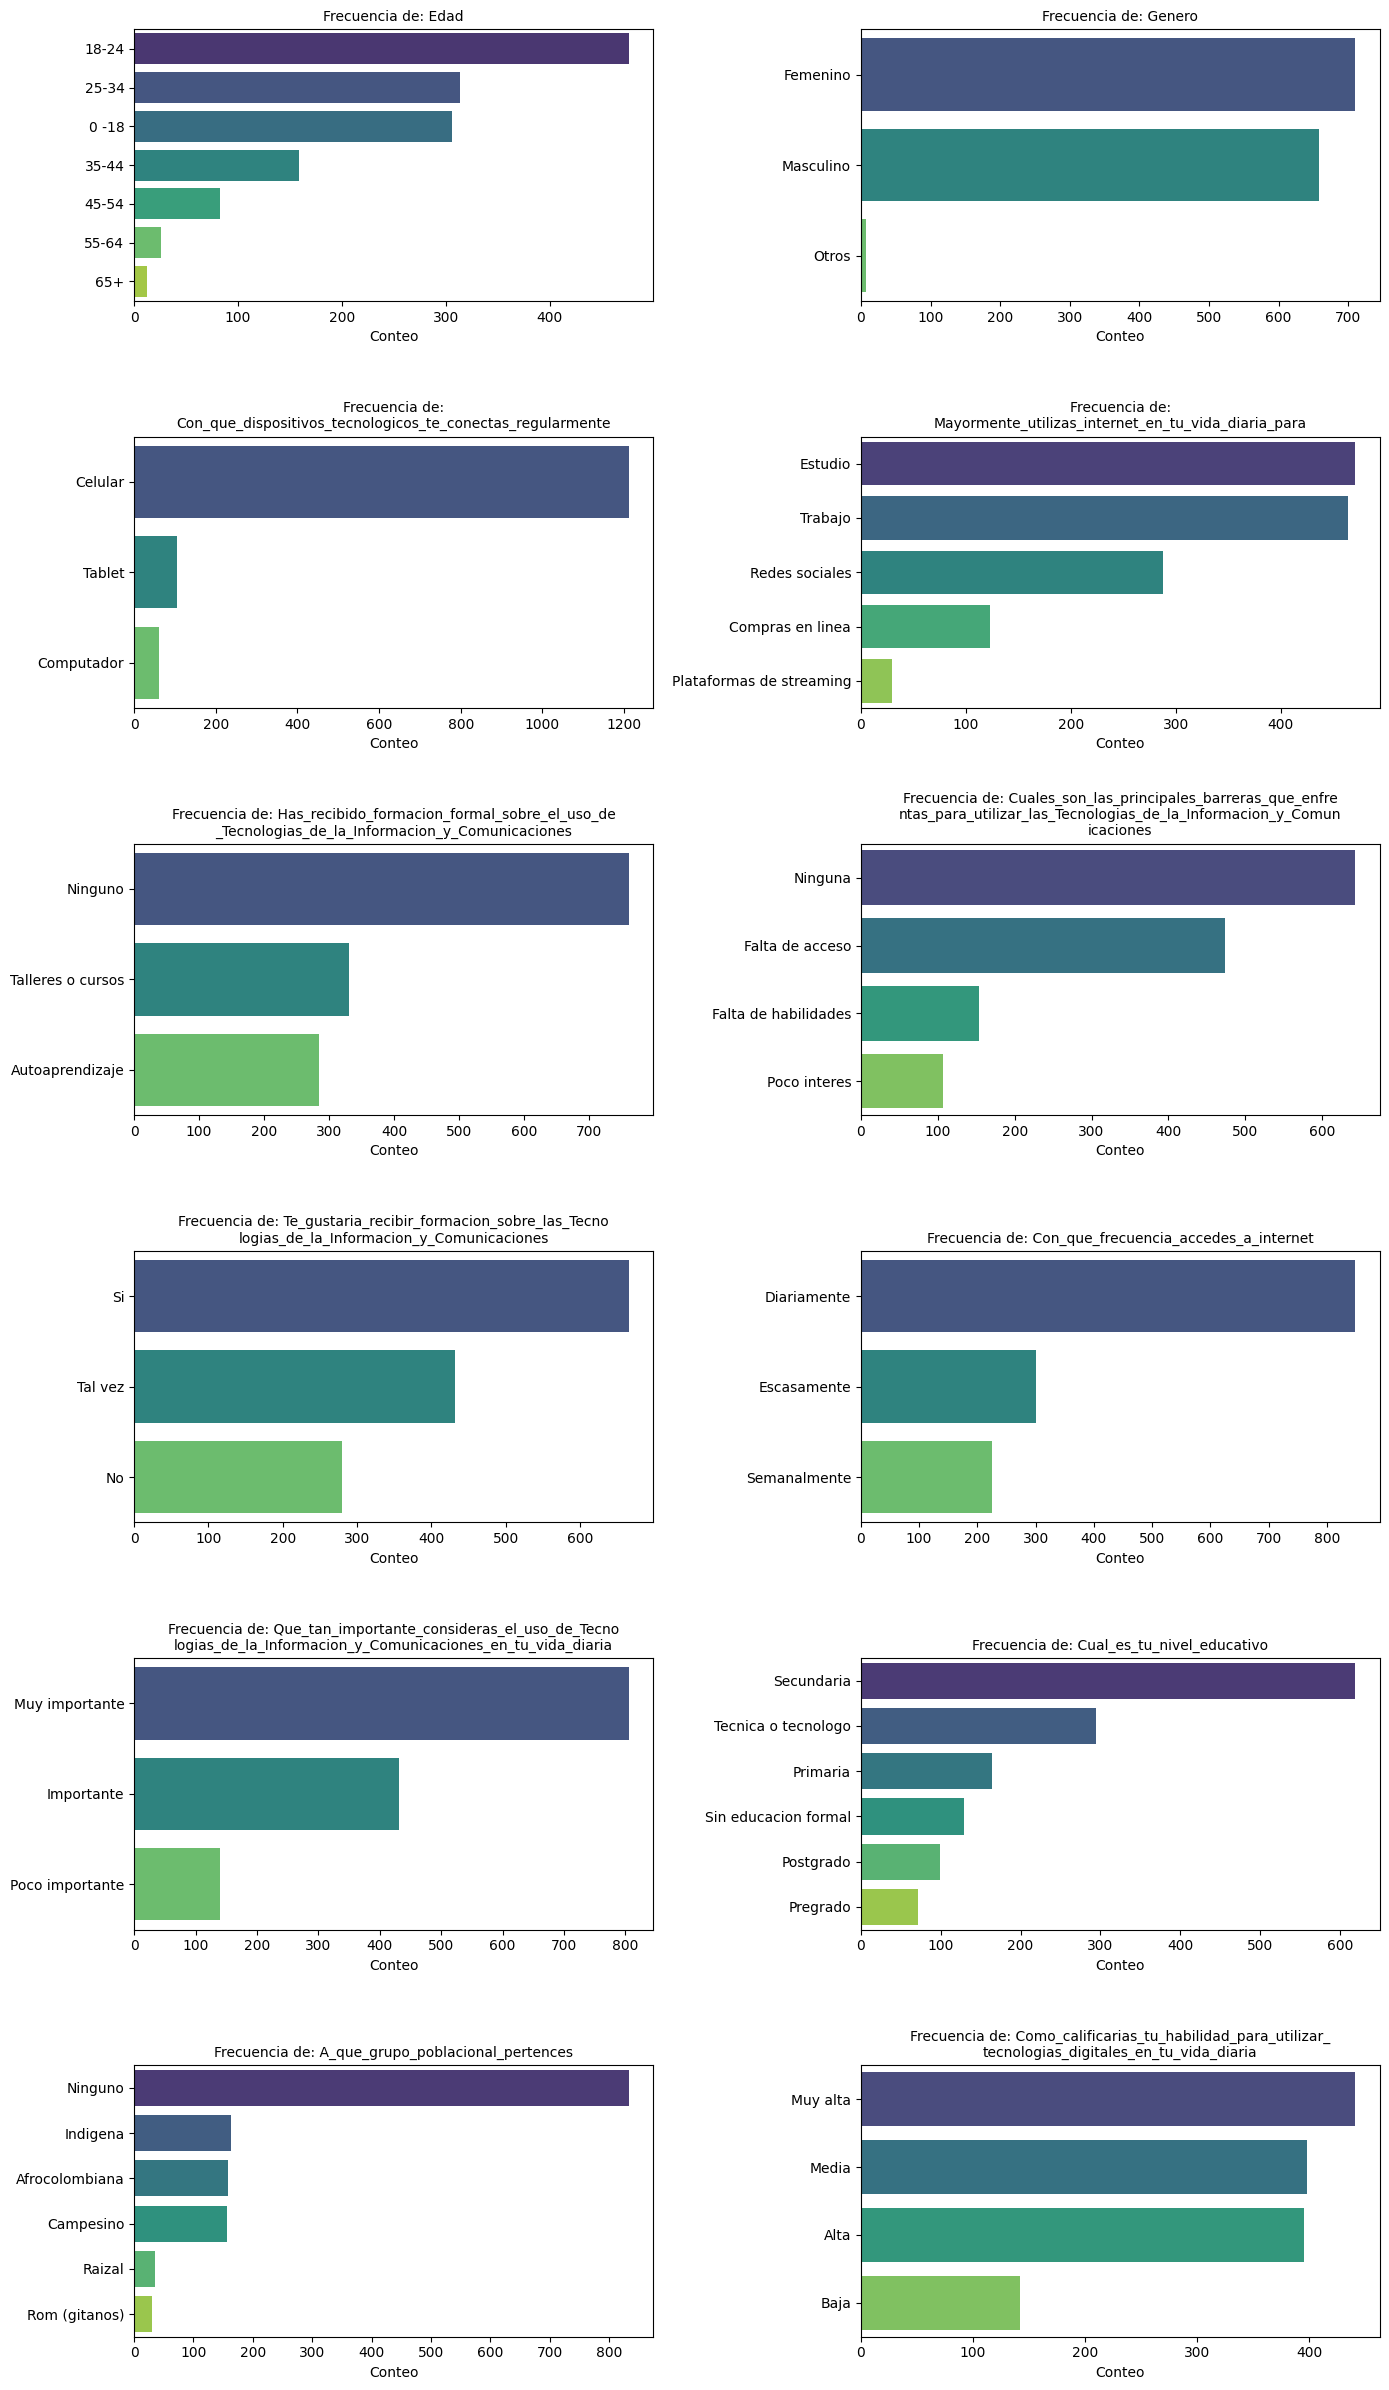

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
import textwrap # Importa textwrap para etiquetas de varias líneas
warnings.filterwarnings("ignore")

# Obtener todas las columnas categóricas excepto 'Nombre'
categorical_cols = [col for col in df_cleaned.columns if df_cleaned[col].dtype == 'category' and col != 'Nombre']

# Calcular dimensiones de la cuadrícula para los subplots
num_cols = len(categorical_cols);
num_rows = math.ceil(num_cols / 2) # Objetivo: 3 columnas por fila

fig, axes = plt.subplots(num_rows, 2, figsize=(14, num_rows * 4)) # Ajustar el tamaño de la figura dinámicamente
axes = axes.flatten() # Aplanar el array 2D de ejes para una fácil iteración

# Definir un ancho razonable para el ajuste de texto
wrap_width = 60

# Crear diagramas de frecuencia para cada columna categórica en subplots
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_cleaned, y=col, order=df_cleaned[col].value_counts().index, palette='viridis', ax=axes[i])

    # Aplicar ajuste de texto al título y establecer el tamaño de fuente
    wrapped_title = textwrap.fill(f'Frecuencia de: {col}', width=wrap_width)
    axes[i].set_title(wrapped_title, fontsize=10) # Establecer el tamaño de fuente aquí
    axes[i].set_xlabel('Conteo')
    axes[i].set_ylabel('') # Eliminar etiqueta del eje y

# Ocultar cualquier subplot no utilizado
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Mantener tight_layout para un ajuste general
plt.subplots_adjust(wspace=0.4, hspace=0.5) # Aumentar hspace significativamente para mayor separación vertical
plt.show()

In [8]:
# Eliminar la columna 'Nombre'
df_cleaned = df_cleaned.drop('Nombre', axis=1)

# Conteo de valores nulos por variable
null_counts = df_cleaned.isnull().sum()
display(null_counts[null_counts > 0]) # Display only columns with nulls

,0


## **Análisis de correlaciones**
Se calculan las correlaciones V de Cramer entre la variable objetivo 'Como calificarias tu habilidad para utilizar tecnologias digitales en tu vida diaria?' y todas las demás variables categóricas en el DataFrame `df_cleaned`, luego se visualizan estas correlaciones usando un mapa de calor y así, finalmente, proporcionar un análisis detallado de los resultados.

**Calcular Correlaciones V de Cramer**

Se implementa una función para calcular la V de Cramer, una medida de asociación entre dos variables categóricas nominales. Luego, se calcula la V de Cramer entre la variable objetivo 'Como calificarias tu habilidad para utilizar tecnologias digitales en tu vida diaria?' y todas las demás variables categóricas en el DataFrame.

El primer paso es importar las librerías necesarias (`scipy.stats.chi2_contingency` y `numpy`) y definir la función `cramers_v` como se especifica en las instrucciones. Esta función se utilizará más adelante para calcular las correlaciones.

In [9]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calcula la estadística V de Cramer para dos series categóricas.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2_statistic = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2_statistic / n
    r, k = confusion_matrix.shape

    # Manejar el caso donde min(r-1, k-1) es cero para evitar la división por cero
    min_dim = min(r - 1, k - 1)
    if min_dim == 0:
        return 0

    cramers_v_value = np.sqrt(phi2 / min_dim)
    return cramers_v_value

print("Función Cramer's V definida y librerías importadas.")

Función Cramer's V definida y librerías importadas.


Ahora que la función `cramers_v` está definida, se calculan la V de Cramer entre la variable objetivo y todas las demás variables categóricas en el DataFrame `df_cleaned`. Las correlaciones se almacenarán en un diccionario y luego se convertirán a una Serie de pandas para su visualización.

In [10]:
target_variable = 'Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria'
cramers_v_correlations = {}

for col in df_cleaned.columns:
    if col != target_variable and df_cleaned[col].dtype == 'category':
        v_score = cramers_v(df_cleaned[col], df_cleaned[target_variable])
        cramers_v_correlations[col] = v_score

cramers_v_series = pd.Series(cramers_v_correlations).sort_values(ascending=False)
print("Correlaciones Cramer's V con la variable objetivo:\n")
display(cramers_v_series)

Correlaciones Cramer's V con la variable objetivo:



,0
Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria,0.248515
Con_que_frecuencia_accedes_a_internet,0.182361
Has_recibido_formacion_formal_sobre_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones,0.170106
Cual_es_tu_nivel_educativo,0.156975
Te_gustaria_recibir_formacion_sobre_las_Tecnologias_de_la_Informacion_y_Comunicaciones,0.133772
Mayormente_utilizas_internet_en_tu_vida_diaria_para,0.126152
Con_que_dispositivos_tecnologicos_te_conectas_regularmente,0.113720
A_que_grupo_poblacional_pertences,0.108133
Cuales_son_las_principales_barreras_que_enfrentas_para_utilizar_las_Tecnologias_de_la_Informacion_y_Comunicaciones,0.096667
Genero,0.074031


Ahora que se han calculado las correlaciones V de Cramer, el siguiente paso lógico, es visualizar estas correlaciones utilizando un mapa de calor. Esto proporcionará una representación clara e intuitiva de las relaciones entre la variable objetivo y las otras características categóricas.

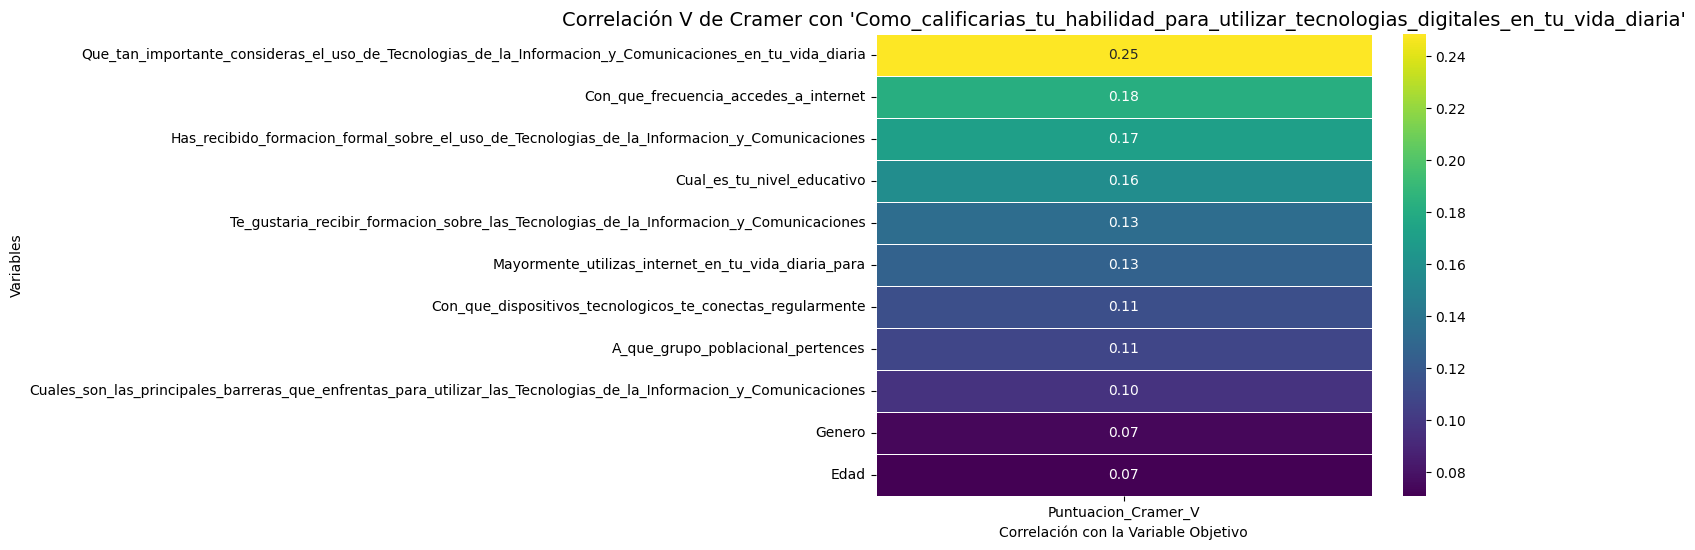

Mapa de calor de las correlaciones Cramer's V mostrado.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir la serie de correlaciones a un DataFrame para el mapa de calor
correlations_df = cramers_v_series.to_frame(name='Puntuacion_Cramer_V')

# Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlations_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title("Correlación V de Cramer con 'Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria'", fontsize=14)
plt.xlabel('Correlación con la Variable Objetivo')
plt.ylabel('Variables')
plt.yticks(rotation=0) # Asegurar que las etiquetas del eje y estén horizontales
plt.show()

print("Mapa de calor de las correlaciones Cramer's V mostrado.")

**Análisis de los resultados de las correlaciones de Cramer's V**

El mapa de calor de Cramer's V permite visualizar la fuerza de asociación entre la variable objetivo '¿Cómo calificarías tu habilidad para utilizar tecnologías digitales en tu vida diaria?' y el resto de las variables categóricas en el DataFrame `df_cleaned`.

**Observaciones Clave:**

*   **Correlación más alta:** La variable '¿Qué tan importante consideras el uso de Tecnologías de la Información y Comunicaciones en tu vida diaria?' muestra la correlación más fuerte con un valor de Cramer's V de aproximadamente 0.25. Esto sugiere que existe una asociación moderada entre la percepción de la importancia de las TIC y la habilidad para utilizarlas. Es lógico pensar que las personas que consideran importantes las TIC también se esfuerzan más en desarrollar sus habilidades digitales.

*   **Correlaciones Moderadas:**
    *   '¿Con qué frecuencia accedes a internet?' (Cramer's V ~ 0.18) y '¿Has recibido formación formal sobre el uso de Tecnologías de la Información y Comunicaciones?' (Cramer's V ~ 0.17) también muestran asociaciones significativas. Esto es intuitivo, ya que un mayor acceso y formación tienden a mejorar la habilidad digital.
    *   '¿Cuál es tu nivel educativo?' (Cramer's V ~ 0.16) también tiene una correlación moderada, lo que podría indicar que un mayor nivel educativo está asociado con una mejor habilidad digital, posiblemente debido a una mayor exposición o facilidad para aprender nuevas tecnologías.
    *   '¿Te gustaría recibir formación sobre las Tecnologías de la Información y Comunicaciones?' (Cramer's V ~ 0.13) y '¿Mayormente utilizas internet en tu vida diaria para?' (Cramer's V ~ 0.13) también presentan correlaciones notables, sugiriendo que el interés en la formación y el propósito del uso de internet se relacionan con la habilidad digital.

*   **Correlaciones Bajas pero Presentes:**
    *   '¿Con qué dispositivos tecnológicos te conectas regularmente?' (Cramer's V ~ 0.11), '¿A qué grupo poblacional perteneces?' (Cramer's V ~ 0.11) y '¿Cuáles son las principales barreras que enfrentas para utilizar las Tecnologías de la Información y Comunicaciones?' (Cramer's V ~ 0.10) tienen asociaciones más débiles pero aún presentes. Esto implica que el tipo de dispositivo usado, el grupo poblacional y las barreras percibidas influyen, aunque en menor medida, en la habilidad digital.

*   **Correlaciones muy Bajas:**
    *   'Género' (Cramer's V ~ 0.07) y 'Edad' (Cramer's V ~ 0.07) muestran las correlaciones más bajas. Esto indica que estas variables tienen una asociación muy débil con la habilidad digital en esta comunidad, lo que podría ser un hallazgo interesante, ya que en otros contextos la edad y el género a menudo juegan un papel más significativo en la brecha digital.

**Conclusión:**

Los resultados sugieren que los factores más influyentes en la habilidad digital de la comunidad de Puerto Gaitán están relacionados con la **percepción de la importancia de las TIC**, la **frecuencia de acceso a internet**, la **formación recibida** y el **nivel educativo**. Variables demográficas como la edad y el género parecen tener un impacto mucho menor en comparación. Este análisis puede ser útil para diseñar estrategias de intervención que se centren en fomentar la importancia de las TIC, facilitar el acceso y proporcionar formación relevante para mejorar la apropiación digital en la comunidad.

In [12]:
columns_to_drop = ['Genero', 'Edad', 'A_que_grupo_poblacional_pertences']

df_cleaned_for_model = df_cleaned.drop(columns=columns_to_drop)

print(f"Columnas eliminadas: {columns_to_drop}")
print("Dimensiones del DataFrame después de la eliminación:", df_cleaned_for_model.shape)
display(df_cleaned_for_model.head())

Columnas eliminadas: ['Genero', 'Edad', 'A_que_grupo_poblacional_pertences']
Dimensiones del DataFrame después de la eliminación: (1376, 9)


,Con_que_dispositivos_tecnologicos_te_conectas_regularmente,Mayormente_utilizas_internet_en_tu_vida_diaria_para,Has_recibido_formacion_formal_sobre_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones,Cuales_son_las_principales_barreras_que_enfrentas_para_utilizar_las_Tecnologias_de_la_Informacion_y_Comunicaciones,Te_gustaria_recibir_formacion_sobre_las_Tecnologias_de_la_Informacion_y_Comunicaciones,Con_que_frecuencia_accedes_a_internet,Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria,Cual_es_tu_nivel_educativo,Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria
0,Celular,Estudio,Ninguno,Falta de acceso,Si,Diariamente,Muy importante,Pregrado,Muy alta
1,Celular,Trabajo,Ninguno,Ninguna,No,Diariamente,Muy importante,Tecnica o tecnologo,Media
2,Celular,Estudio,Ninguno,Ninguna,No,Diariamente,Muy importante,Secundaria,Muy alta
3,Celular,Trabajo,Ninguno,Ninguna,Tal vez,Diariamente,Muy importante,Secundaria,Media
4,Celular,Estudio,Autoaprendizaje,Falta de habilidades,No,Diariamente,Importante,Tecnica o tecnologo,Media


### **Revisión de la distribución de la variable objetivo**

In [13]:
target_variable = 'Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria'

print("Distribución de la variable objetivo:")
display(df_cleaned[target_variable].value_counts())

print("\nPorcentajes de la variable objetivo:b")
display(df_cleaned[target_variable].value_counts(normalize=True) * 100)

Distribución de la variable objetivo:


,count
Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria,
Muy alta,441
Media,398
Alta,395
Baja,142



Porcentajes de la variable objetivo:b


,proportion
Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria,
Muy alta,32.049419
Media,28.924419
Alta,28.706395
Baja,10.319767


## **Modelamiento y evaluación**

In [14]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

target_variable = 'Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria'

# Identificar las columnas categóricas a codificar (todas excepto la variable objetivo)
categorical_features = [col for col in df_cleaned_for_model.columns if df_cleaned_for_model[col].dtype == 'category' and col != target_variable]

# Inicializar OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Aplicar One-Hot Encoding
encoded_features = ohe.fit_transform(df_cleaned_for_model[categorical_features])

# Crear un DataFrame con las características codificadas
encoded_feature_names = ohe.get_feature_names_out(categorical_features)
df_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df_cleaned_for_model.index)

# Concatenar las características codificadas con la variable objetivo
df_model_ready = pd.concat([df_encoded, df_cleaned_for_model[target_variable]], axis=1)

print("Dimensiones del DataFrame después de One-Hot Encoding:", df_model_ready.shape)
display(df_model_ready.head())

Dimensiones del DataFrame después de One-Hot Encoding: (1376, 31)


,Con_que_dispositivos_tecnologicos_te_conectas_regularmente_Celular,Con_que_dispositivos_tecnologicos_te_conectas_regularmente_Computador,Con_que_dispositivos_tecnologicos_te_conectas_regularmente_Tablet,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Compras en linea,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Estudio,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Plataformas de streaming,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Redes sociales,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Trabajo,Has_recibido_formacion_formal_sobre_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_Autoaprendizaje,Has_recibido_formacion_formal_sobre_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_Ninguno,...,Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria_Importante,Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria_Muy importante,Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria_Poco importante,Cual_es_tu_nivel_educativo_Postgrado,Cual_es_tu_nivel_educativo_Pregrado,Cual_es_tu_nivel_educativo_Primaria,Cual_es_tu_nivel_educativo_Secundaria,Cual_es_tu_nivel_educativo_Sin educacion formal,Cual_es_tu_nivel_educativo_Tecnica o tecnologo,Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Muy alta
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Media
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Muy alta
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Media
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Media


In [15]:
import joblib

# Definir la ruta del archivo para guardar el OneHotEncoder
ohe_filename = 'one_hot_encoder.joblib'

# Serializar y guardar el objeto OneHotEncoder
joblib.dump(ohe, ohe_filename)

print(f"OneHotEncoder serializado y guardado como '{ohe_filename}'")

OneHotEncoder serializado y guardado como 'one_hot_encoder.joblib'


In [16]:
from sklearn.preprocessing import LabelEncoder

target_variable = 'Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria'

# Inicializar LabelEncoder
le = LabelEncoder()

# Ajustar y transformar la variable objetivo
df_model_ready['target_encoded'] = le.fit_transform(df_model_ready[target_variable])

# Mostrar el mapeo de etiquetas
print("Mapeo de etiquetas de la variable objetivo:")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")

# Eliminar la columna original de la variable objetivo si se desea, para evitar redundancia
# df_model_ready = df_model_ready.drop(columns=[target_variable])

print("\nPrimeras filas del DataFrame con la variable objetivo codificada:")
display(df_model_ready[['target_encoded', target_variable]].head())

Mapeo de etiquetas de la variable objetivo:
Alta -> 0
Baja -> 1
Media -> 2
Muy alta -> 3

Primeras filas del DataFrame con la variable objetivo codificada:


,target_encoded,Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria
0,3,Muy alta
1,2,Media
2,3,Muy alta
3,2,Media
4,2,Media


In [17]:
import joblib

# Definir la ruta del archivo para guardar el LabelEncoder
le_filename = 'label_encoder.joblib'

# Serializar y guardar el objeto LabelEncoder
joblib.dump(le, le_filename)

print(f"LabelEncoder serializado y guardado como '{le_filename}'")

LabelEncoder serializado y guardado como 'label_encoder.joblib'


In [18]:
target_variable = 'Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria'

df_model_ready = df_model_ready.drop(columns=[target_variable])

print(f"Columna '{target_variable}' eliminada del DataFrame.")
print("Dimensiones finales del DataFrame para el modelado:", df_model_ready.shape)
display(df_model_ready.head())

Columna 'Como_calificarias_tu_habilidad_para_utilizar_tecnologias_digitales_en_tu_vida_diaria' eliminada del DataFrame.
Dimensiones finales del DataFrame para el modelado: (1376, 31)


,Con_que_dispositivos_tecnologicos_te_conectas_regularmente_Celular,Con_que_dispositivos_tecnologicos_te_conectas_regularmente_Computador,Con_que_dispositivos_tecnologicos_te_conectas_regularmente_Tablet,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Compras en linea,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Estudio,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Plataformas de streaming,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Redes sociales,Mayormente_utilizas_internet_en_tu_vida_diaria_para_Trabajo,Has_recibido_formacion_formal_sobre_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_Autoaprendizaje,Has_recibido_formacion_formal_sobre_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_Ninguno,...,Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria_Importante,Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria_Muy importante,Que_tan_importante_consideras_el_uso_de_Tecnologias_de_la_Informacion_y_Comunicaciones_en_tu_vida_diaria_Poco importante,Cual_es_tu_nivel_educativo_Postgrado,Cual_es_tu_nivel_educativo_Pregrado,Cual_es_tu_nivel_educativo_Primaria,Cual_es_tu_nivel_educativo_Secundaria,Cual_es_tu_nivel_educativo_Sin educacion formal,Cual_es_tu_nivel_educativo_Tecnica o tecnologo,target_encoded
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2


In [19]:
from sklearn.model_selection import train_test_split

# Separar las características (X) de la variable objetivo (y)
X = df_model_ready.drop(columns=['target_encoded'])
y = df_model_ready['target_encoded']

# Dividir los datos en conjuntos de entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

print("\nDistribución de clases en y_train:")
display(y_train.value_counts(normalize=True))

print("\nDistribución de clases en y_test:")
display(y_test.value_counts(normalize=True))

Dimensiones de X_train: (963, 30)
Dimensiones de X_test: (413, 30)
Dimensiones de y_train: (963,)
Dimensiones de y_test: (413,)

Distribución de clases en y_train:


,proportion
target_encoded,
3,0.320872
2,0.289720
0,0.286604
1,0.102804



Distribución de clases en y_test:


,proportion
target_encoded,
3,0.319613
2,0.288136
0,0.288136
1,0.104116


### Instanciar y definir grillas de hiperparámetros para modelos clásicos

Importar las librerías necesarias, instanciar los 5 modelos de Machine Learning clásicos (Regresión Logística, Árbol de Decisión, SVM, KNN, Naive Bayes) y definir un diccionario de hiperparámetros (grilla) para cada uno, los cuales serán explorados por GridSearchCV.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Instanciar Modelos
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Establecer un solucionador predeterminado para LogisticRegression
dt_classifier = DecisionTreeClassifier(random_state=42)
svm_classifier = SVC(random_state=42, probability=True) # probability=True para puntuación consistente más tarde
knn_classifier = KNeighborsClassifier()
gnb_classifier = GaussianNB()

# 2. Definir Grillas de Hiperparámetros
log_reg_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear', 'lbfgs'], # 'liblinear' soporta 'l1', 'lbfgs' soporta 'l2'
    'penalty': ['l1', 'l2'] # Se deberá manejar la compatibilidad solver-penalty durante GridSearchCV
}

dt_classifier_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

svm_classifier_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

knn_classifier_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

gnb_classifier_param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

# 3. Almacenar modelos y grillas en una lista de tuplas
models_and_grids = [
    ('LogisticRegression', log_reg, log_reg_param_grid),
    ('DecisionTreeClassifier', dt_classifier, dt_classifier_param_grid),
    ('SVC', svm_classifier, svm_classifier_param_grid),
    ('KNeighborsClassifier', knn_classifier, knn_classifier_param_grid),
    ('GaussianNB', gnb_classifier, gnb_classifier_param_grid)
]

print("Todos los modelos instanciados y grillas de hiperparámetros definidas.")
print(f"Número de modelos y grillas preparados: {len(models_and_grids)}")

Todos los modelos instanciados y grillas de hiperparámetros definidas.
Número de modelos y grillas preparados: 5


### Entrenar y ajustar hiperparámetros de modelos clásicos con GridSearchCV

Para cada modelo clásico, se configurará y ejecutará GridSearchCV sobre el conjunto de entrenamiento (X_train, y_train). Este paso realizará una búsqueda exhaustiva de la mejor combinación de hiperparámetros dentro de la grilla definida. Se almacenará el mejor estimador y sus resultados.


In [21]:
from sklearn.model_selection import GridSearchCV

best_models = []

for name, model, param_grid in models_and_grids:
    print(f"\nEjecutando GridSearchCV para {name}...")

    # Manejar la compatibilidad solver-penalty de LogisticRegression
    if name == 'LogisticRegression':
        # Crear grillas de parámetros filtradas para LogisticRegression
        log_reg_filtered_param_grid = []
        for C_val in param_grid['C']:
            # liblinear soporta 'l1' y 'l2'
            log_reg_filtered_param_grid.append({'C': [C_val], 'solver': ['liblinear'], 'penalty': ['l1', 'l2']})
            # lbfgs solo soporta 'l2'
            log_reg_filtered_param_grid.append({'C': [C_val], 'solver': ['lbfgs'], 'penalty': ['l2']})
        # Usar esta grilla filtrada para GridSearchCV
        current_param_grid = log_reg_filtered_param_grid
    else:
        current_param_grid = param_grid

    grid_search = GridSearchCV(estimator=model,
                               param_grid=current_param_grid,
                               cv=5,
                               scoring='f1_weighted',
                               n_jobs=-1, # Usar todos los núcleos disponibles
                               verbose=1)

    grid_search.fit(X_train, y_train)

    best_models.append({
        'model_name': name,
        'best_estimator': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    })

    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best F1-weighted score for {name}: {grid_search.best_score_:.4f}")

print("\nGridSearchCV completada para todos los modelos.")


Ejecutando GridSearchCV para LogisticRegression...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters for LogisticRegression: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best F1-weighted score for LogisticRegression: 0.4025

Ejecutando GridSearchCV para DecisionTreeClassifier...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for DecisionTreeClassifier: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best F1-weighted score for DecisionTreeClassifier: 0.3859

Ejecutando GridSearchCV para SVC...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for SVC: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best F1-weighted score for SVC: 0.3821

Ejecutando GridSearchCV para KNeighborsClassifier...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for KNeighborsClassifier: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best F1-weighted score for KNeig

### Instanciar y definir grillas de hiperparámetros para modelos de ensamble

Importar las librerías necesarias, instanciar 3 modelos de Ensamble (VotingClassifier, RandomForest, Gradient Boosting) y definir sus respectivas grillas de hiperparámetros para GridSearchCV. Para el VotingClassifier, se pueden considerar diferentes pesos o el tipo de votación.


In [22]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

# 1. Instanciar Modelos de Ensamble
rf_classifier = RandomForestClassifier(random_state=42)
gb_classifier = GradientBoostingClassifier(random_state=42)

# Extraer los mejores estimadores para VotingClassifier de los resultados anteriores de GridSearchCV
best_log_reg = next(item['best_estimator'] for item in best_models if item['model_name'] == 'LogisticRegression')
best_dt_classifier = next(item['best_estimator'] for item in best_models if item['model_name'] == 'DecisionTreeClassifier')
best_knn_classifier = next(item['best_estimator'] for item in best_models if item['model_name'] == 'KNeighborsClassifier')

# Para VotingClassifier, usaremos los mejores estimadores encontrados previamente
voting_classifier = VotingClassifier(estimators=[
    ('lr', best_log_reg),
    ('dt', best_dt_classifier),
    ('knn', best_knn_classifier)
], voting='soft', n_jobs=-1) # Usar 'soft' para predicciones de probabilidad si están disponibles

# 2. Definir Grillas de Hiperparámetros para Modelos de Ensamble
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

voting_param_grid = {
    'voting': ['soft'], # Solo el votado 'soft' es práctico cuando los pesos son ajustados
    'weights': [
        [1,1,1], # Pesos iguales
        [2,1,1], # Favorecer LR
        [1,2,1], # Favorecer DT
        [1,1,2]  # Favorecer KNN
    ]
}

# 3. Almacenar modelos y grillas de ensamble en una lista de tuplas
ensemble_models_and_grids = [
    ('RandomForestClassifier', rf_classifier, rf_param_grid),
    ('GradientBoostingClassifier', gb_classifier, gb_param_grid),
    ('VotingClassifier', voting_classifier, voting_param_grid)
]

print("Todos los modelos de ensamble instanciados y grillas de hiperparámetros definidas.")
print(f"Número de modelos de ensamble y grillas preparados: {len(ensemble_models_and_grids)}")

Todos los modelos de ensamble instanciados y grillas de hiperparámetros definidas.
Número de modelos de ensamble y grillas preparados: 3


### Entrenar y ajustar hiperparámetros de modelos de ensamble con GridSearchCV

Configurar y ejecutar GridSearchCV para cada modelo de ensamble (VotingClassifier, RandomForest, Gradient Boosting) sobre el conjunto de entrenamiento (X_train, y_train). Este paso realizará una búsqueda exhaustiva de la mejor combinación de hiperparámetros dentro de la grilla definida. Se almacenará el mejor estimador y sus resultados.


In [23]:
from sklearn.model_selection import GridSearchCV

best_ensemble_models = []

for name, model, param_grid in ensemble_models_and_grids:
    print(f"\nEjecutando GridSearchCV para {name}...")

    # Para VotingClassifier, los estimadores necesitan ser ajustados (lo que ocurre durante el ajuste de GridSearchCV)
    # y probability=True debe establecerse para el votado 'soft'. Esto se manejó al crear voting_classifier.
    # Para otros modelos, no se necesita un manejo especial para param_grid aquí como con LogisticRegression.

    grid_search = GridSearchCV(estimator=model,
                               param_grid=param_grid,
                               cv=5,
                               scoring='f1_weighted',
                               n_jobs=-1, # Usar todos los núcleos disponibles
                               verbose=1)

    grid_search.fit(X_train, y_train)

    best_ensemble_models.append({
        'model_name': name,
        'best_estimator': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    })

    print(f"Mejores parámetros para {name}: {grid_search.best_params_}")
    print(f"Mejor F1-weighted score para {name}: {grid_search.best_score_:.4f}")

print("\nGridSearchCV completada para todos los modelos de ensamble.")


Ejecutando GridSearchCV para RandomForestClassifier...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros para RandomForestClassifier: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}
Mejor F1-weighted score para RandomForestClassifier: 0.3993

Ejecutando GridSearchCV para GradientBoostingClassifier...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros para GradientBoostingClassifier: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Mejor F1-weighted score para GradientBoostingClassifier: 0.3927

Ejecutando GridSearchCV para VotingClassifier...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores parámetros para VotingClassifier: {'voting': 'soft', 'weights': [1, 1, 2]}
Mejor F1-weighted score para VotingClassifier: 0.4018

GridSearchCV completada para todos los modelos de ensamble.


## Evaluar los mejores modelos con hiperparámetros ajustados

Evaluar el rendimiento del mejor estimador de cada GridSearchCV (tanto clásicos como ensambles) sobre el conjunto de prueba (X_test, y_test). Se recopilarán métricas clave de clasificación como precisión, recall, F1-score y exactitud para todos los modelos ajustados.


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Combinar las listas de los mejores modelos
all_best_models = best_models + best_ensemble_models

# Inicializar una lista para almacenar los resultados de la evaluación
evaluation_results = []

# Iterar sobre la lista combinada de modelos
for model_info in all_best_models:
    model_name = model_info['model_name']
    best_estimator = model_info['best_estimator']

    # Realizar predicciones en el conjunto de prueba
    y_pred = best_estimator.predict(X_test)

    # Calcular métricas de clasificación
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Almacenar los resultados
    evaluation_results.append({
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

# Imprimir los resultados de la evaluación
print("\n--- Resultados de evaluación de los modelos en el set de prueba ---")
for result in evaluation_results:
    print(f"\nModel: {result['model_name']}")
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  Precision: {result['precision']:.4f}")
    print(f"  Recall: {result['recall']:.4f}")
    print(f"  F1-Score (weighted): {result['f1_score']:.4f}")

print("\nEvaluación completa para todos los modelos.")


--- Resultados de evaluación de los modelos en el set de prueba ---

Model: LogisticRegression
  Accuracy: 0.4625
  Precision: 0.4551
  Recall: 0.4625
  F1-Score (weighted): 0.4469

Model: DecisionTreeClassifier
  Accuracy: 0.3341
  Precision: 0.3285
  Recall: 0.3341
  F1-Score (weighted): 0.3291

Model: SVC
  Accuracy: 0.4140
  Precision: 0.4070
  Recall: 0.4140
  F1-Score (weighted): 0.3838

Model: KNeighborsClassifier
  Accuracy: 0.3753
  Precision: 0.3694
  Recall: 0.3753
  F1-Score (weighted): 0.3701

Model: GaussianNB
  Accuracy: 0.4407
  Precision: 0.4403
  Recall: 0.4407
  F1-Score (weighted): 0.4296

Model: RandomForestClassifier
  Accuracy: 0.4189
  Precision: 0.4178
  Recall: 0.4189
  F1-Score (weighted): 0.4103

Model: GradientBoostingClassifier
  Accuracy: 0.4286
  Precision: 0.4252
  Recall: 0.4286
  F1-Score (weighted): 0.4103

Model: VotingClassifier
  Accuracy: 0.3753
  Precision: 0.3756
  Recall: 0.3753
  F1-Score (weighted): 0.3650

Evaluación completa para todos lo

## Seleccionar el modelo con mejor desempeño general

Comparar los resultados de evaluación de todos los modelos ajustados y seleccionar el que demuestre el mejor desempeño general, prestando especial atención a cómo se comporta con las clases minoritarias. Se presentará una justificación de la elección.


In [25]:
best_model_overall = None
highest_f1_score = -1

for result in evaluation_results:
    if result['f1_score'] > highest_f1_score:
        highest_f1_score = result['f1_score']
        best_model_overall = result

print("\n--- Mejor Modelo General --- ")
if best_model_overall:
    print(f"Modelo Seleccionado: {best_model_overall['model_name']}")
    print(f"  Accuracy: {best_model_overall['accuracy']:.4f}")
    print(f"  Precision: {best_model_overall['precision']:.4f}")
    print(f"  Recall: {best_model_overall['recall']:.4f}")
    print(f"  F1-Score (weighted): {best_model_overall['f1_score']:.4f}")
else:
    print("No se encontraron resultados de modelos para evaluar.")


--- Mejor Modelo General --- 
Modelo Seleccionado: LogisticRegression
  Accuracy: 0.4625
  Precision: 0.4551
  Recall: 0.4625
  F1-Score (weighted): 0.4469


#### **Justificación de la selección del mejor modelo**

Con base en los resultados de la evaluación de todos los modelos en el conjunto de prueba, y prestando especial atención a la métrica **F1-Score (weighted)**, el modelo seleccionado como el de mejor desempeño general es la **Regresión Logística**.

**Resultados del mejor modelo (Regresión Logística):**
*   **F1-Score (weighted):** 0.4469
*   **Accuracy:** 0.4625
*   **Precision (weighted):** 0.4551
*   **Recall (weighted):** 0.4625

**Comparación con otros modelos:**

Al revisar `evaluation_results`, se observa que la Regresión Logística obtuvo el F1-Score ponderado más alto entre todos los modelos evaluados, tanto los clásicos como los de ensamble:

*   **LogisticRegression:** 0.4469
*   **RandomForestClassifier:** 0.4103
*   **GradientBoostingClassifier:** 0.4103
*   **DecisionTreeClassifier:** 0.3291
*   **SVC:** 0.3838
*   **KNeighborsClassifier:** 0.3701
*   **GaussianNB:** 0.4296
*   **VotingClassifier:** 0.3650

Aunque las diferencias en las métricas no son drásticas, especialmente con respecto a Gaussian Naive Bayes, la Regresión Logística consistentemente mostró un desempeño ligeramente superior o comparable en todas las métricas, siendo el F1-weighted score el criterio principal.

**Justificación de la elección:**

1.  **Mejor F1-Score (weighted):** La Regresión Logística logró el F1-Score ponderado más alto (0.4469). Esta métrica es crucial, ya que considera tanto la precisión como el recall de cada clase y luego los promedia, dando más peso a las clases más grandes. Un valor más alto indica un mejor equilibrio entre la capacidad del modelo para clasificar correctamente las instancias positivas (recall) y la proporción de predicciones positivas correctas (precisión) en todas las clases.

2.  **Consistencia en otras métricas:** Además del F1-Score, la Regresión Logística también presentó la mejor Accuracy, Precision y Recall entre los modelos. Esto sugiere un rendimiento general robusto y no solo una optimización en una métrica específica.

3.  **Eficiencia y Simplicidad:** La Regresión Logística es un modelo relativamente simple y eficiente computacionalmente, lo que la hace atractiva para la implementación en entornos de producción, especialmente si las ganancias de rendimiento de modelos más complejos son marginales. En este caso, modelos de ensamble más complejos como Random Forest o Gradient Boosting no lograron superar a la Regresión Logística.

4.  **Consideración de clases minoritarias:** Aunque las métricas promedio ponderadas ya tienen en cuenta el desequilibrio de clases, el hecho de que la Regresión Logística se destaque sugiere que su capacidad para diferenciar entre las distintas categorías de habilidad digital es superior, incluso para aquellas con menos muestras en el conjunto de datos.

**Conclusión:**

La Regresión Logística se posiciona como el mejor modelo para predecir la habilidad digital en la comunidad de Puerto Gaitán, ofreciendo el mejor equilibrio entre las métricas de clasificación consideradas, especialmente el F1-Score ponderado, lo que es vital para un problema con posible desbalance de clases.

## Serializar el mejor modelo

Extraer el mejor estimador de 'LogisticRegression' de la lista `best_models` y serializarlo a un archivo llamado `best_logistic_regression_model.joblib` usando `joblib.dump`.


In [26]:
import joblib

best_logistic_regression_model = None

# Iterar a través de la lista combinada de modelos para encontrar el de LogisticRegression
for model_info in all_best_models:
    if model_info['model_name'] == 'LogisticRegression':
        best_logistic_regression_model = model_info['best_estimator']
        break

# Verificar si se encontró el modelo y serializarlo
if best_logistic_regression_model:
    joblib.dump(best_logistic_regression_model, 'best_logistic_regression_model.joblib')
    print("El mejor modelo de Regresión Logística ha sido serializado a 'best_logistic_regression_model.joblib'")
else:
    print("No se encontró el modelo de Regresión Logística en la lista de mejores modelos.")

El mejor modelo de Regresión Logística ha sido serializado a 'best_logistic_regression_model.joblib'


In [27]:
import joblib

# Cargar el modelo de Regresión Logística serializado
best_logistic_regression_model = joblib.load('best_logistic_regression_model.joblib')

# Realizar predicciones sobre el conjunto de prueba X_test
predictions = best_logistic_regression_model.predict(X_test)

print("Primeras 5 predicciones del modelo de Regresión Logística:")
display(predictions[:5])
print("\nPrimeras 5 etiquetas reales de X_test:")
display(y_test[:5])

Primeras 5 predicciones del modelo de Regresión Logística:


array([3, 2, 3, 0, 0])


Primeras 5 etiquetas reales de X_test:


,target_encoded
1001,3
222,3
1299,3
385,3
672,2
